In [1]:
import pandas as pd

acc_df = pd.read_csv("train_acc.csv")
loss_df = pd.read_csv("train_loss.csv")
fl_acc_df = pd.read_csv("fl_train_acc.csv")
fl_loss_df = pd.read_csv("fl_train_loss.csv")

loss_df.columns = [col.replace(' - train_loss', '') for col in loss_df.columns]
acc_df.columns = [col.replace(' - train_acc', '') for col in acc_df.columns]
fl_acc_df.columns = [col.replace(' - train_acc', '') for col in fl_acc_df.columns]
fl_loss_df.columns = [col.replace(' - train_loss', '') for col in fl_loss_df.columns]

print(acc_df.columns.tolist())

cols_to_keep = ['trainer/global_step',
                 'cnn-8', 'cnn-4', 'cnn-2','cnn-1',
                 'fc512', 'fc256', 'fc128', 'fc1024']
acc_df = acc_df[cols_to_keep]
loss_df = loss_df[cols_to_keep]
fl_acc_df = fl_acc_df[cols_to_keep]
fl_loss_df = fl_loss_df[cols_to_keep]



['trainer/global_step', 'cnn-8 - _step', 'cnn-8 - _step__MIN', 'cnn-8 - _step__MAX', 'cnn-8', 'cnn-8__MIN', 'cnn-8__MAX', 'cnn-4 - _step', 'cnn-4 - _step__MIN', 'cnn-4 - _step__MAX', 'cnn-4', 'cnn-4__MIN', 'cnn-4__MAX', 'cnn-2 - _step', 'cnn-2 - _step__MIN', 'cnn-2 - _step__MAX', 'cnn-2', 'cnn-2__MIN', 'cnn-2__MAX', 'cnn-1 - _step', 'cnn1 - _step__MIN', 'cnn1 - _step__MAX', 'cnn-1', 'cnn-1__MIN', 'cnn-1__MAX', 'fc512 - _step', 'fc512 - _step__MIN', 'fc512 - _step__MAX', 'fc512', 'fc512__MIN', 'fc512__MAX', 'fc256 - _step', 'fc256 - _step__MIN', 'fc256 - _step__MAX', 'fc256', 'fc256__MIN', 'fc256__MAX', 'fc128 - _step', 'fc128 - _step__MIN', 'fc128 - _step__MAX', 'fc128', 'fc128__MIN', 'fc128__MAX', 'fc1024 - _step', 'fc1024 - _step__MIN', 'fc1024 - _step__MAX', 'fc1024', 'fc1024__MIN', 'fc1024__MAX', 'fc2048 - _step', 'fc2048 - _step__MIN', 'fc2048 - _step__MAX', 'fc2048', 'fc2048__MIN', 'fc2048__MAX']


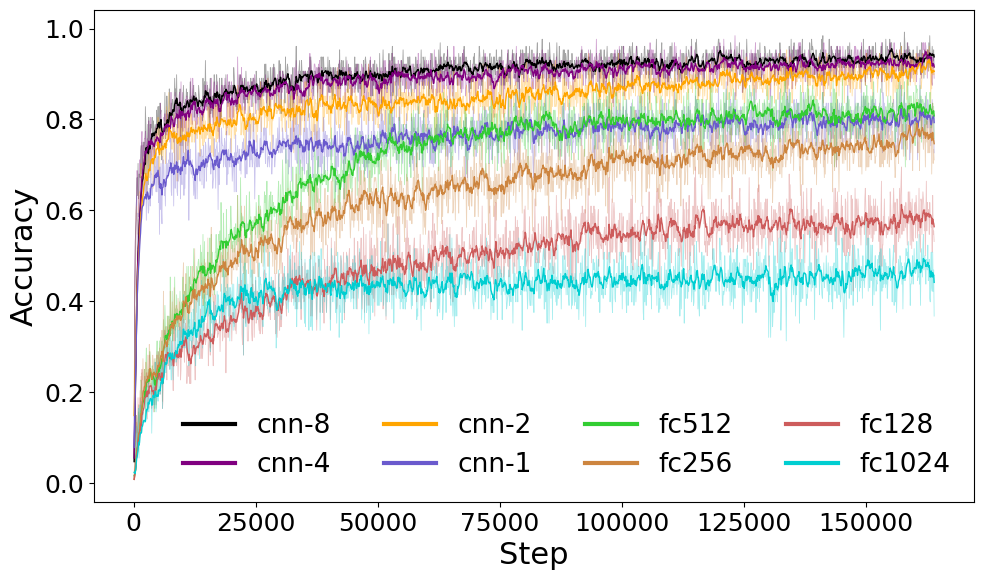

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 10

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(acc_df[x_col], acc_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = acc_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(acc_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=22)
plt.ylabel('Accuracy', fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)

handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=19)
plt.subplots_adjust(top=0.93)
plt.subplots_adjust(left=0.1)
plt.subplots_adjust(right=0.98)




plt.savefig("train_acc.png")

plt.show()


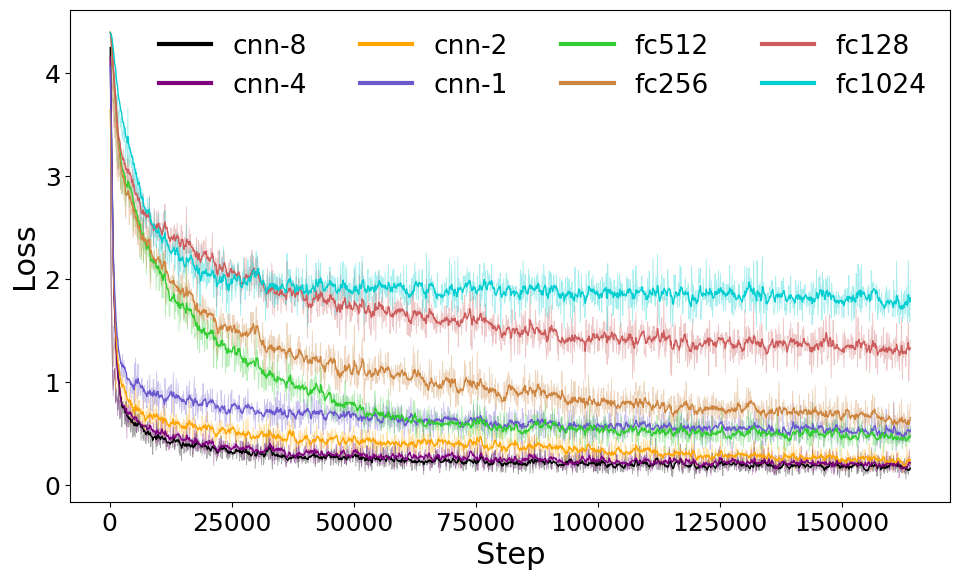

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 10

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(loss_df[x_col], loss_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = loss_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(loss_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=22)
plt.ylabel('Loss', fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=19)
plt.subplots_adjust(top=0.93)
plt.subplots_adjust(left=0.1)
plt.subplots_adjust(right=0.98)



plt.savefig("train_loss.png")

plt.show()

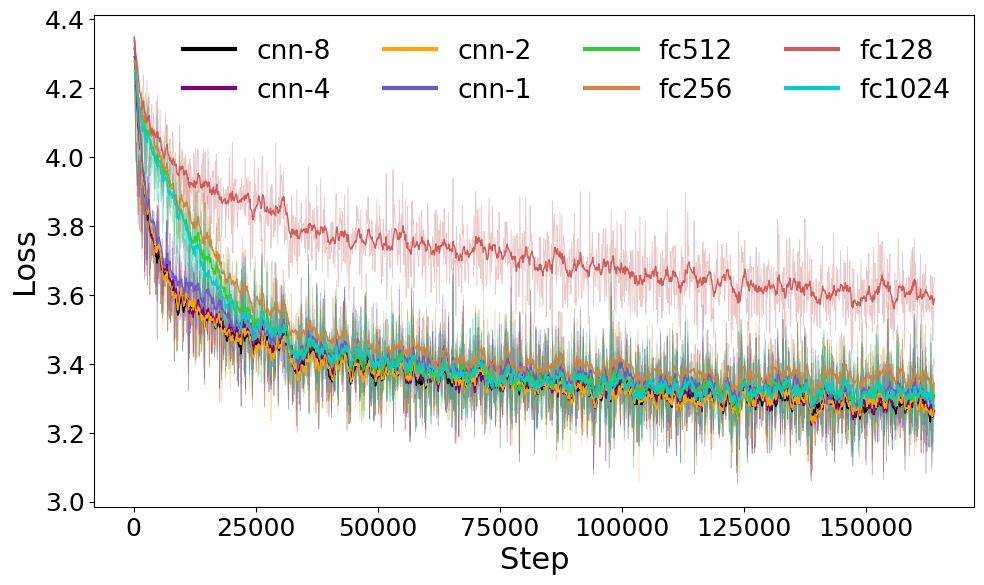

In [7]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 15

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(fl_loss_df[x_col], fl_loss_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = fl_loss_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(fl_loss_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=22)
plt.ylabel('Loss', fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=19)
plt.subplots_adjust(top=0.93)
plt.subplots_adjust(left=0.1)
plt.subplots_adjust(right=0.98)



plt.savefig("fl_train_loss.png")

plt.show()

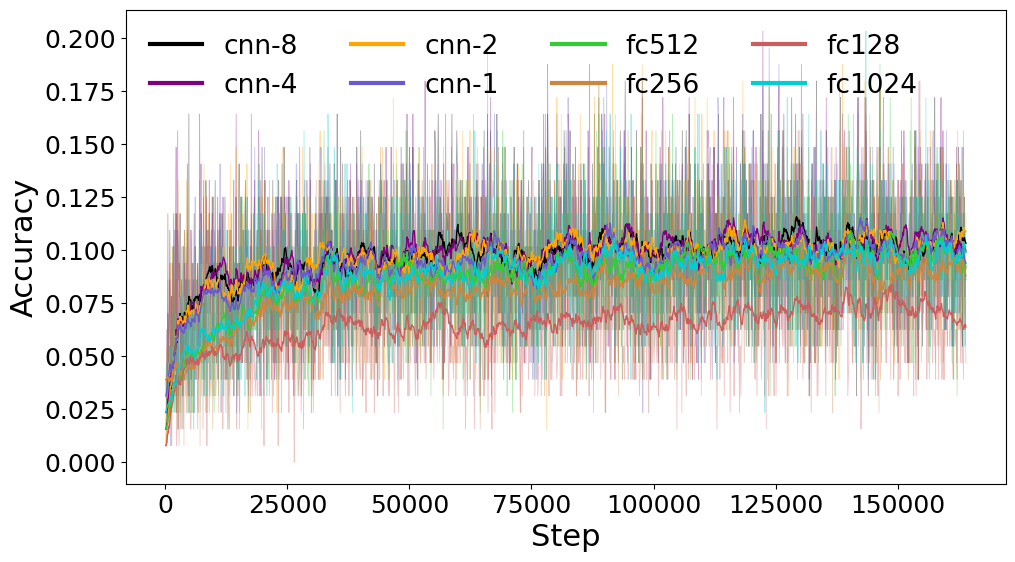

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x_col = 'trainer/global_step'
y_cols = cols_to_keep

colors = ['black', 'purple', 'orange', 'slateblue', 'limegreen', 'peru', 'indianred', 'darkturquoise']
ema_span = 30

plt.figure(figsize=(10, 6))

for i in range(1, 9):
    plt.plot(fl_acc_df[x_col], fl_acc_df[y_cols[i]], color=colors[i-1], linewidth=0.6, alpha=0.35)

for i in range(1, 9):
    ema = fl_acc_df[y_cols[i]].ewm(span=ema_span, adjust=False).mean()
    plt.plot(fl_acc_df[x_col], ema, color=colors[i-1], linewidth=1)  # bold EMA

plt.xlabel('Step', fontsize=22)
plt.ylabel('Accuracy', fontsize=22)
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
handles = [Line2D([0], [0], color=colors[i-1], lw=3.0) for i in range(1, 9)]
plt.legend(handles, y_cols[1:9], ncol=4, frameon=False, fontsize=19)
plt.subplots_adjust(top=0.90)
plt.subplots_adjust(left=0.10)
plt.subplots_adjust(right=0.98)



plt.savefig("fl_train_acc.png")

plt.show()